# Notification Priority Classification - Data Exploration & Analysis

**Authors:** Oliver Holmes, Sofia Bonoan, Denis Sokolov, Gonzalo Fernández  
**Project:** Notification Priority Classification Using Semantic Analysis  
**Dataset:** Curated NLP Notifications Dataset (NLP_Notifications_final.dataset.csv)

This notebook explores and analyzes our curated notification dataset for semantic priority classification. We will:

1. Load and explore our curated notification dataset with real text content
2. Analyze the urgency distribution and notification characteristics
3. Examine notification content for semantic patterns
4. Evaluate the preprocessing pipeline output
5. Prepare insights for transformer model training
6. Generate visualizations for the research paper

---

## 1. Import Required Packages

Let's import all the necessary packages for data analysis, visualization, and text processing.

In [1]:
# Essential imports for data analysis (avoiding pandas/seaborn due to compatibility issues)
import os
import sys
import csv
import re
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')

print("✓ Essential packages imported successfully!")
print(f"Current working directory: {os.getcwd()}")

# Add project root to path for importing our preprocessing script
project_root = Path.cwd().parent
sys.path.append(str(project_root))

✓ Essential packages imported successfully!
Current working directory: /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/notebooks


## 2. Load Curated Notification Dataset

We're using our own curated dataset with real notification text content suitable for semantic analysis. This dataset contains authentic notifications with urgency labels (High, Medium, Low) that we'll use to train our transformer-based classification models.

In [2]:
# Load our curated notification dataset
def load_notification_data(filename="../NLP_Notifications_final.dataset.csv"):
    """Load the curated notification dataset with real text content."""
    
    filepath = Path(filename)
    if not filepath.exists():
        print(f"❌ Dataset not found at {filepath}")
        print(f"   Current directory: {Path.cwd()}")
        return None
    
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            data.append(row)
    
    print(f"✓ Successfully loaded {len(data)} notifications from {filepath.name}")
    return data

def display_data_info(data):
    """Display basic information about the dataset."""
    if not data:
        return
        
    print(f"\nDataset Overview:")
    print(f"  Total notifications: {len(data)}")
    print(f"  Features: {list(data[0].keys())}")
    
    # Show sample notifications
    print(f"\nSample notifications:")
    for i, row in enumerate(data[:3]):
        print(f"  {i+1}. [{row['urgency'].upper()}] {row['app_name']}: {row['notif_content'][:60]}...")

# Load the dataset
raw_data = load_notification_data()
if raw_data:
    display_data_info(raw_data)

✓ Successfully loaded 737 notifications from NLP_Notifications_final.dataset.csv

Dataset Overview:
  Total notifications: 737
  Features: ['timestamp', 'app_name', 'notif_type', 'notif_content', 'urgency']

Sample notifications:
  1. [HIGH] Clock: Alarm: Take out the trash before 8 AM pickup....
  2. [LOW] Chase Bank: Payment of $9.99 to Netflix processed successfully....
  3. [LOW] Revolut: You spent €42.30 at Zara. Remaining budget: €157.70....


## 3. Comprehensive Dataset Analysis

Now let's perform a comprehensive analysis of our curated notification dataset to understand urgency patterns, app distributions, and semantic characteristics.

In [3]:
# Comprehensive analysis of our curated notification dataset
def analyze_urgency_distribution(data):
    """Analyze the distribution of urgency levels."""
    urgency_counts = Counter(row['urgency'].lower() for row in data)
    
    print("📊 URGENCY DISTRIBUTION")
    print("=" * 50)
    total = len(data)
    
    for urgency in ['high', 'medium', 'low']:
        count = urgency_counts[urgency]
        pct = count / total * 100
        print(f"  {urgency.upper():6}: {count:3d} notifications ({pct:5.1f}%)")
    
    return urgency_counts

def analyze_apps_and_types(data):
    """Analyze app sources and notification types."""
    app_counts = Counter(row['app_name'] for row in data)
    type_counts = Counter(row['notif_type'] for row in data)
    
    print("\n📱 TOP APPS (by notification frequency)")
    print("=" * 50)
    for app, count in app_counts.most_common(10):
        pct = count / len(data) * 100
        print(f"  {app:15}: {count:3d} ({pct:4.1f}%)")
    
    print("\n🔔 NOTIFICATION TYPES")
    print("=" * 50)
    for ntype, count in sorted(type_counts.items()):
        pct = count / len(data) * 100
        print(f"  {ntype:10}: {count:3d} ({pct:4.1f}%)")
    
    return app_counts, type_counts

def analyze_content_characteristics(data):
    """Analyze notification content characteristics."""
    lengths = [len(row['notif_content']) for row in data]
    words = [len(row['notif_content'].split()) for row in data]
    
    print("\n📝 CONTENT CHARACTERISTICS")
    print("=" * 50)
    print(f"Character length:")
    print(f"  Mean:   {np.mean(lengths):6.1f} characters")
    print(f"  Median: {np.median(lengths):6.1f} characters")
    print(f"  Max:    {max(lengths):6d} characters")
    print(f"  Min:    {min(lengths):6d} characters")
    
    print(f"Word count:")
    print(f"  Mean:   {np.mean(words):6.1f} words")
    print(f"  Median: {np.median(words):6.1f} words")
    print(f"  Max:    {max(words):6d} words")
    print(f"  Min:    {min(words):6d} words")
    
    return lengths, words

def display_sample_notifications(data, n_per_urgency=3):
    """Display sample notifications for each urgency level."""
    print(f"\n📋 SAMPLE NOTIFICATIONS ({n_per_urgency} per urgency level)")
    print("=" * 80)
    
    by_urgency = defaultdict(list)
    for row in data:
        by_urgency[row['urgency'].lower()].append(row)
    
    for urgency in ['high', 'medium', 'low']:
        print(f"\n🔴 {urgency.upper()} URGENCY:")
        print("-" * 40)
        for i, row in enumerate(by_urgency[urgency][:n_per_urgency]):
            content = row['notif_content'][:80] + "..." if len(row['notif_content']) > 80 else row['notif_content']
            print(f"  {i+1}. [{row['app_name']}] {content}")

# Run comprehensive analysis
if raw_data:
    urgency_dist = analyze_urgency_distribution(raw_data)
    app_counts, type_counts = analyze_apps_and_types(raw_data)
    lengths, words = analyze_content_characteristics(raw_data)
    display_sample_notifications(raw_data)

📊 URGENCY DISTRIBUTION
  HIGH  : 258 notifications ( 35.0%)
  MEDIUM: 196 notifications ( 26.6%)
  LOW   : 283 notifications ( 38.4%)

📱 TOP APPS (by notification frequency)
  Gmail          :  69 ( 9.4%)
  WhatsApp       :  69 ( 9.4%)
  Whatsapp       :  62 ( 8.4%)
  Instagram      :  36 ( 4.9%)
  iOS            :  31 ( 4.2%)
  Messages       :  28 ( 3.8%)
  Clock          :  25 ( 3.4%)
  Slack          :  21 ( 2.8%)
  Revolut        :  20 ( 2.7%)
  LinkedIn       :  20 ( 2.7%)

🔔 NOTIFICATION TYPES
  alert     : 141 (19.1%)
  email     :  77 (10.4%)
  message   : 264 (35.8%)
  ping      : 147 (19.9%)
  reminder  : 108 (14.7%)

📝 CONTENT CHARACTERISTICS
Character length:
  Mean:     55.3 characters
  Median:   54.0 characters
  Max:       382 characters
  Min:         2 characters
Word count:
  Mean:      9.3 words
  Median:    9.0 words
  Max:        66 words
  Min:         1 words

📋 SAMPLE NOTIFICATIONS (3 per urgency level)

🔴 HIGH URGENCY:
----------------------------------------

## 4. Semantic Content Analysis

Now let's analyze the semantic patterns in notification content to understand how urgency is expressed through text.

In [4]:
# Semantic analysis functions for notification content
def extract_urgency_keywords(data):
    """Extract keywords that commonly appear in each urgency level."""
    
    urgency_text = defaultdict(list)
    for row in data:
        urgency_text[row['urgency'].lower()].append(row['notif_content'].lower())
    
    # Combine all text for each urgency level
    urgency_combined = {level: ' '.join(texts) for level, texts in urgency_text.items()}
    
    # Extract common words (very basic tokenization)
    import re
    urgency_words = {}
    for level, text in urgency_combined.items():
        # Simple word extraction (keeping important punctuation)
        words = re.findall(r'\b\w+\b', text)
        word_freq = Counter(words)
        # Filter out very common words
        common_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did'}
        filtered_words = {word: count for word, count in word_freq.items() if word not in common_words and len(word) > 2}
        urgency_words[level] = Counter(filtered_words).most_common(15)
    
    print("🔍 URGENCY-SPECIFIC KEYWORDS")
    print("=" * 60)
    for level in ['high', 'medium', 'low']:
        print(f"\n{level.upper()} URGENCY keywords:")
        for word, count in urgency_words[level]:
            print(f"  {word:15}: {count:3d}")
    
    return urgency_words

def analyze_punctuation_patterns(data):
    """Analyze punctuation patterns that might indicate urgency."""
    
    urgency_punct = defaultdict(list)
    for row in data:
        content = row['notif_content']
        urgency = row['urgency'].lower()
        
        # Count different punctuation
        exclamation_count = content.count('!')
        question_count = content.count('?')
        uppercase_ratio = sum(1 for c in content if c.isupper()) / len(content) if content else 0
        
        urgency_punct[urgency].append({
            'exclamation': exclamation_count,
            'question': question_count,
            'uppercase_ratio': uppercase_ratio
        })
    
    print("\n❗ PUNCTUATION & CASE ANALYSIS")
    print("=" * 50)
    
    for level in ['high', 'medium', 'low']:
        punct_data = urgency_punct[level]
        avg_exclamation = np.mean([p['exclamation'] for p in punct_data])
        avg_question = np.mean([p['question'] for p in punct_data])
        avg_uppercase = np.mean([p['uppercase_ratio'] for p in punct_data])
        
        print(f"\n{level.upper()} urgency patterns:")
        print(f"  Avg exclamation marks: {avg_exclamation:.2f}")
        print(f"  Avg question marks:    {avg_question:.2f}")
        print(f"  Avg uppercase ratio:   {avg_uppercase:.3f}")

def analyze_time_sensitive_words(data):
    """Look for time-sensitive language that might indicate urgency."""
    
    time_words = {
        'immediate': ['now', 'immediately', 'urgent', 'asap', 'quickly', 'right away'],
        'time_specific': ['minutes', 'hours', 'today', 'tomorrow', 'deadline', 'expires', 'ending'],
        'action_required': ['please', 'required', 'must', 'need', 'verify', 'confirm', 'action'],
        'warning': ['failed', 'error', 'warning', 'alert', 'problem', 'issue', 'critical']
    }
    
    urgency_time_patterns = defaultdict(lambda: defaultdict(int))
    
    for row in data:
        content = row['notif_content'].lower()
        urgency = row['urgency'].lower()
        
        for category, words in time_words.items():
            for word in words:
                if word in content:
                    urgency_time_patterns[urgency][category] += 1
    
    print("\n⏰ TIME-SENSITIVE LANGUAGE PATTERNS")
    print("=" * 60)
    
    for level in ['high', 'medium', 'low']:
        print(f"\n{level.upper()} urgency - time-sensitive words:")
        for category, count in urgency_time_patterns[level].items():
            print(f"  {category:15}: {count:3d} occurrences")

# Run semantic analysis
if raw_data:
    urgency_keywords = extract_urgency_keywords(raw_data)
    analyze_punctuation_patterns(raw_data)
    analyze_time_sensitive_words(raw_data)

🔍 URGENCY-SPECIFIC KEYWORDS

HIGH URGENCY keywords:
  your           : 162
  minutes        :  50
  code           :  50
  you            :  48
  account        :  33
  this           :  30
  name           :  27
  detected       :  25
  critical       :  22
  please         :  21
  call           :  20
  alert          :  18
  can            :  18
  new            :  18
  flight         :  17

MEDIUM URGENCY keywords:
  your           :  88
  you            :  62
  available      :  20
  from           :  19
  before         :  15
  match          :  14
  opportunity    :  14
  storage        :  14
  rsvp           :  12
  will           :  12
  reminder       :  11
  this           :  11
  call           :  11
  received       :  11
  update         :  11

LOW URGENCY keywords:
  your           :  89
  you            :  70
  name           :  48
  sent           :  23
  new            :  16
  team           :  14
  lunch          :  14
  available      :  13
  today          :  12
  

In [5]:
# Simple text analysis without heavy plotting
if df_raw is not None:
    
    # Identify text columns
    text_columns = []
    for col in df_raw.columns:
        if any(keyword in col.lower() for keyword in ['text', 'title', 'body', 'message', 'content', 'notification']):
            text_columns.append(col)
    
    print(f"🔤 Identified text columns: {text_columns}")
    
    # Simple text statistics
    if text_columns:
        print(f"\n📊 Text Statistics:")
        for col in text_columns:
            text_series = df_raw[col].astype(str)
            non_empty = text_series[text_series.str.len() > 0]
            
            print(f"\n{col}:")
            print(f"  Non-empty entries: {len(non_empty)}/{len(df_raw)} ({len(non_empty)/len(df_raw)*100:.1f}%)")
            if len(non_empty) > 0:
                lengths = non_empty.str.len()
                print(f"  Length stats: min={lengths.min()}, max={lengths.max()}, mean={lengths.mean():.1f}")
                print(f"  Sample: '{non_empty.iloc[0][:80]}...'")
    
    # Check for potential priority/urgency columns
    priority_columns = []
    for col in df_raw.columns:
        if any(keyword in col.lower() for keyword in ['priority', 'urgency', 'importance', 'level', 'class', 'label']):
            priority_columns.append(col)
    
    print(f"\n🎯 Potential priority columns: {priority_columns}")
    
    if priority_columns:
        for col in priority_columns:
            print(f"\n{col} values:")
            print(df_raw[col].value_counts().head(5))

NameError: name 'df_raw' is not defined

## 5. Preprocessed Data Analysis

Let's examine the results of our preprocessing pipeline and the train/validation/test splits.

In [ ]:
# Load and analyze the preprocessed splits
def load_processed_splits():
    """Load the preprocessed train/val/test splits."""
    
    processed_dir = Path("../data/processed")
    splits = {}
    
    for split_name in ['train', 'val', 'test']:
        filepath = processed_dir / f"notifications_{split_name}.csv"
        
        if not filepath.exists():
            print(f"⚠️ {filepath} not found. Please run preprocessing first.")
            continue
            
        data = []
        with open(filepath, 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                data.append(row)
        
        splits[split_name] = data
        print(f"✓ Loaded {len(data)} notifications from {split_name} split")
    
    return splits

def analyze_split_distributions(splits):
    """Analyze the distribution of urgency levels across splits."""
    
    print("\n📊 SPLIT DISTRIBUTIONS")
    print("=" * 60)
    
    for split_name, split_data in splits.items():
        print(f"\n{split_name.upper()} SET ({len(split_data)} notifications):")
        urgency_dist = Counter(row['urgency'] for row in split_data)
        
        for urgency in ['high', 'medium', 'low']:
            count = urgency_dist[urgency]
            pct = count / len(split_data) * 100 if split_data else 0
            print(f"  {urgency.capitalize():6}: {count:3d} ({pct:5.1f}%)")

def check_preprocessing_quality(splits):
    """Check the quality of preprocessing (anonymization, cleaning)."""
    
    print("\n🔒 PREPROCESSING QUALITY CHECK")
    print("=" * 60)
    
    # Patterns to check for proper anonymization
    sensitive_patterns = {
        'emails': re.compile(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'),
        'urls': re.compile(r'https?://[^\s]+'),
        'long_numbers': re.compile(r'\b\d{4,}\b')  # 4+ digit numbers
    }
    
    anonymization_placeholders = ['<EMAIL>', '<URL>', '<PHONE>', '<NUMBER>', '<AMOUNT>', '<NAME>']
    
    all_data = []
    for split_data in splits.values():
        all_data.extend(split_data)
    
    print(f"Analyzing {len(all_data)} preprocessed notifications...")
    
    # Check for remaining sensitive info
    sensitive_found = defaultdict(int)
    placeholder_found = defaultdict(int)
    
    for row in all_data:
        content = row['notif_content']
        
        # Check for sensitive patterns
        for pattern_name, pattern in sensitive_patterns.items():
            if pattern.search(content):
                sensitive_found[pattern_name] += 1
                
        # Check for anonymization placeholders
        for placeholder in anonymization_placeholders:
            if placeholder in content:
                placeholder_found[placeholder] += 1
    
    print(f"\n🔍 Sensitive Information Found:")
    for pattern_name, count in sensitive_found.items():
        if count > 0:
            print(f"  ⚠️ {pattern_name}: {count} instances")
        else:
            print(f"  ✓ {pattern_name}: None found")
    
    print(f"\n🔒 Anonymization Placeholders:")
    for placeholder, count in placeholder_found.items():
        if count > 0:
            print(f"  ✓ {placeholder}: {count} instances")
    
    total_sensitive = sum(sensitive_found.values())
    total_placeholders = sum(placeholder_found.values())
    
    if total_sensitive == 0 and total_placeholders > 0:
        print(f"\n✅ Privacy protection successful! {total_placeholders} sensitive items anonymized.")
    elif total_sensitive > 0:
        print(f"\n⚠️ Privacy concern: {total_sensitive} sensitive items may need attention.")
    
    return sensitive_found, placeholder_found

# Load the processed splits
try:
    processed_splits = load_processed_splits()
    if processed_splits:
        analyze_split_distributions(processed_splits)
        sensitive_found, placeholder_found = check_preprocessing_quality(processed_splits)
    else:
        print("No processed splits found. Please run the preprocessing script first.")
except Exception as e:
    print(f"Error loading processed splits: {str(e)}")
    print("Please ensure the preprocessing has been completed successfully.")

✓ Loaded 519 notifications from train split
✓ Loaded 109 notifications from val split
✓ Loaded 109 notifications from test split

📊 SPLIT DISTRIBUTIONS

TRAIN SET (519 notifications):
  High  : 182 ( 35.1%)
  Medium: 138 ( 26.6%)
  Low   : 199 ( 38.3%)

VAL SET (109 notifications):
  High  :  38 ( 34.9%)
  Medium:  29 ( 26.6%)
  Low   :  42 ( 38.5%)

TEST SET (109 notifications):
  High  :  38 ( 34.9%)
  Medium:  29 ( 26.6%)
  Low   :  42 ( 38.5%)

🔒 PREPROCESSING QUALITY CHECK
Analyzing 737 preprocessed notifications...

🔍 Sensitive Information Found:

🔒 Anonymization Placeholders:
  ✓ <AMOUNT>: 62 instances
  ✓ <NAME>: 85 instances
  ✓ <URL>: 2 instances
  ✓ <NUMBER>: 5 instances
  ✓ <EMAIL>: 1 instances

✅ Privacy protection successful! 155 sensitive items anonymized.


## 6. 📊 Publication-Quality Visualizations

Creating professional visualizations for academic paper presentation. These graphs illustrate key findings from our notification priority classification dataset and preprocessing pipeline.

In [ ]:
# Enhanced imports for publication-quality visualizations
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from collections import Counter, defaultdict
import re
from wordcloud import WordCloud
import textwrap

# Set publication-ready style
plt.style.use('default')
sns.set_palette("husl")

# Color schemes for consistency
URGENCY_COLORS = {
    'high': '#d62728',      # Red for high urgency
    'medium': '#ff7f0e',    # Orange for medium urgency 
    'low': '#2ca02c'        # Green for low urgency
}

APP_COLORS = sns.color_palette("tab10", n_colors=10)
SPLIT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Configure matplotlib for high-quality output
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 16,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.transparent': True
})

print("✅ Enhanced visualization packages imported!")
print("📊 Publication-ready plotting configuration applied!")

✅ Enhanced visualization packages imported!
📊 Publication-ready plotting configuration applied!


In [ ]:
def create_urgency_distribution_plot(data, title="Notification Urgency Distribution"):
    """Create a professional urgency distribution visualization."""
    
    # Count urgency levels
    urgency_counts = Counter([item['urgency'] for item in data])
    
    # Prepare data
    urgencies = ['high', 'medium', 'low']
    counts = [urgency_counts.get(urgency, 0) for urgency in urgencies]
    percentages = [count/sum(counts)*100 for count in counts]
    colors = [URGENCY_COLORS[urgency] for urgency in urgencies]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Bar plot
    bars1 = ax1.bar(urgencies, counts, color=colors, alpha=0.8, edgecolor='white', linewidth=1)
    ax1.set_title(f'{title}\n(Total: {sum(counts)} notifications)', fontweight='bold', pad=20)
    ax1.set_xlabel('Urgency Level')
    ax1.set_ylabel('Number of Notifications')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, count, pct in zip(bars1, counts, percentages):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    wedges, texts, autotexts = ax2.pie(counts, labels=[f'{u.capitalize()}' for u in urgencies], 
                                      colors=colors, autopct='%1.1f%%', startangle=90,
                                      textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax2.set_title('Urgency Distribution', fontweight='bold', pad=20)
    
    # Enhance pie chart text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    return fig

def create_app_distribution_plot(data, top_n=10):
    """Create app distribution visualization."""
    
    app_counts = Counter([item['app_name'] for item in data])
    top_apps = app_counts.most_common(top_n)
    
    apps, counts = zip(*top_apps)
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(apps)), counts, color=APP_COLORS[:len(apps)], alpha=0.8)
    
    # Customize
    ax.set_yticks(range(len(apps)))
    ax.set_yticklabels([app.title() for app in apps])
    ax.set_xlabel('Number of Notifications')
    ax.set_title(f'Top {top_n} Apps by Notification Count\n(Total: {sum(app_counts.values())} notifications)',
                fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, count) in enumerate(zip(bars, counts)):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
               f'{count}', ha='left', va='center', fontweight='bold')
    
    # Invert y-axis so highest is on top
    ax.invert_yaxis()
    
    plt.tight_layout()
    return fig

def create_text_length_analysis(data):
    """Analyze and visualize notification text lengths."""
    
    # Calculate text lengths
    lengths_by_urgency = defaultdict(list)
    for item in data:
        content = item['notif_content']
        length = len(content.split())  # Word count
        lengths_by_urgency[item['urgency']].append(length)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Distribution by urgency (box plot)
    urgencies = ['high', 'medium', 'low']
    data_for_box = [lengths_by_urgency[urgency] for urgency in urgencies]
    colors_for_box = [URGENCY_COLORS[urgency] for urgency in urgencies]
    
    box_plot = axes[0,0].boxplot(data_for_box, labels=[u.capitalize() for u in urgencies], 
                                patch_artist=True)
    
    for patch, color in zip(box_plot['boxes'], colors_for_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[0,0].set_title('Text Length Distribution by Urgency', fontweight='bold')
    axes[0,0].set_xlabel('Urgency Level')
    axes[0,0].set_ylabel('Word Count')
    axes[0,0].grid(alpha=0.3)
    
    # Overall histogram
    all_lengths = [len(item['notif_content'].split()) for item in data]
    axes[0,1].hist(all_lengths, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    axes[0,1].set_title('Overall Text Length Distribution', fontweight='bold')
    axes[0,1].set_xlabel('Word Count')
    axes[0,1].set_ylabel('Frequency')
    axes[0,1].grid(alpha=0.3)
    
    # Statistics by urgency
    stats_data = []
    for urgency in urgencies:
        lengths = lengths_by_urgency[urgency]
        if lengths:
            stats_data.append([
                urgency.capitalize(),
                len(lengths),
                np.mean(lengths),
                np.median(lengths),
                np.std(lengths)
            ])
    
    # Statistics table
    axes[1,0].axis('tight')
    axes[1,0].axis('off')
    table_data = [['Urgency', 'Count', 'Mean', 'Median', 'Std Dev']] + \
                 [[row[0], f'{row[1]}', f'{row[2]:.1f}', f'{row[3]:.1f}', f'{row[4]:.1f}'] 
                  for row in stats_data]
    
    table = axes[1,0].table(cellText=table_data[1:], colLabels=table_data[0],
                           cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2)
    
    # Color code table rows
    for i, urgency in enumerate(urgencies):
        for j in range(len(table_data[0])):
            table[(i+1, j)].set_facecolor(URGENCY_COLORS[urgency.lower()])
            table[(i+1, j)].set_alpha(0.3)
    
    axes[1,0].set_title('Text Length Statistics', fontweight='bold')
    
    # Cumulative distribution
    for urgency in urgencies:
        lengths = sorted(lengths_by_urgency[urgency])
        if lengths:
            y_values = np.arange(1, len(lengths) + 1) / len(lengths)
            axes[1,1].plot(lengths, y_values, label=urgency.capitalize(), 
                          color=URGENCY_COLORS[urgency], linewidth=2)
    
    axes[1,1].set_title('Cumulative Text Length Distribution', fontweight='bold')
    axes[1,1].set_xlabel('Word Count')
    axes[1,1].set_ylabel('Cumulative Probability')
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

print("✅ Visualization functions created!")
print("📊 Ready to generate publication-quality graphs!")

✅ Visualization functions created!
📊 Ready to generate publication-quality graphs!


In [ ]:
def create_data_splits_visualization(splits_data):
    """Visualize train/validation/test splits and their distributions."""
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Split sizes
    split_names = list(splits_data.keys())
    split_sizes = [len(splits_data[split]) for split in split_names]
    total_size = sum(split_sizes)
    
    # Pie chart for split proportions
    wedges, texts, autotexts = axes[0,0].pie(split_sizes, labels=[s.capitalize() for s in split_names], 
                                            colors=SPLIT_COLORS[:len(split_names)], autopct='%1.1f%%',
                                            startangle=90, textprops={'fontweight': 'bold'})
    axes[0,0].set_title(f'Dataset Split Distribution\n(Total: {total_size} notifications)', fontweight='bold')
    
    for autotext in autotexts:
        autotext.set_color('white')
    
    # Bar chart for split sizes
    bars = axes[0,1].bar(split_names, split_sizes, color=SPLIT_COLORS[:len(split_names)], alpha=0.8)
    axes[0,1].set_title('Dataset Split Sizes', fontweight='bold')
    axes[0,1].set_ylabel('Number of Notifications')
    
    # Add value labels
    for bar, size in zip(bars, split_sizes):
        height = bar.get_height()
        axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 5,
                      f'{size}', ha='center', va='bottom', fontweight='bold')
    
    # Urgency distribution across splits
    urgency_data = []
    for split_name in split_names:
        split_urgency = Counter([item['urgency'] for item in splits_data[split_name]])
        urgency_data.append([split_urgency.get('high', 0), 
                           split_urgency.get('medium', 0), 
                           split_urgency.get('low', 0)])
    
    urgency_data = np.array(urgency_data)
    
    # Stacked bar chart
    bottom = np.zeros(len(split_names))
    urgency_labels = ['High', 'Medium', 'Low']
    urgency_colors = ['#d62728', '#ff7f0e', '#2ca02c']
    
    for i, (urgency, color) in enumerate(zip(urgency_labels, urgency_colors)):
        axes[1,0].bar(split_names, urgency_data[:, i], bottom=bottom, 
                     label=urgency, color=color, alpha=0.8)
        bottom += urgency_data[:, i]
    
    axes[1,0].set_title('Urgency Distribution Across Splits', fontweight='bold')
    axes[1,0].set_ylabel('Number of Notifications')
    axes[1,0].legend()
    
    # Proportional stacked bar (percentage)
    proportional_data = urgency_data / urgency_data.sum(axis=1).reshape(-1, 1) * 100
    
    bottom_prop = np.zeros(len(split_names))
    for i, (urgency, color) in enumerate(zip(urgency_labels, urgency_colors)):
        axes[1,1].bar(split_names, proportional_data[:, i], bottom=bottom_prop,
                     label=urgency, color=color, alpha=0.8)
        
        # Add percentage labels
        for j, split_name in enumerate(split_names):
            if proportional_data[j, i] > 5:  # Only show if > 5%
                axes[1,1].text(j, bottom_prop[j] + proportional_data[j, i]/2,
                              f'{proportional_data[j, i]:.1f}%',
                              ha='center', va='center', fontweight='bold', color='white')
        
        bottom_prop += proportional_data[:, i]
    
    axes[1,1].set_title('Urgency Distribution (Proportional)', fontweight='bold')
    axes[1,1].set_ylabel('Percentage')
    axes[1,1].legend()
    axes[1,1].set_ylim(0, 100)
    
    plt.tight_layout()
    return fig

def create_preprocessing_quality_visualization(data):
    """Visualize preprocessing quality and anonymization results."""
    
    # Check for anonymization patterns
    anonymization_patterns = {
        '<EMAIL>': len(re.findall(r'<EMAIL>', ' '.join([item['notif_content'] for item in data]))),
        '<URL>': len(re.findall(r'<URL>', ' '.join([item['notif_content'] for item in data]))),
        '<PHONE>': len(re.findall(r'<PHONE>', ' '.join([item['notif_content'] for item in data]))),
        '<NUMBER>': len(re.findall(r'<NUMBER>', ' '.join([item['notif_content'] for item in data]))),
        '<AMOUNT>': len(re.findall(r'<AMOUNT>', ' '.join([item['notif_content'] for item in data]))),
    }
    
    # Text quality metrics
    all_content = ' '.join([item['notif_content'] for item in data])
    
    quality_metrics = {
        'Total Words': len(all_content.split()),
        'Unique Words': len(set(all_content.lower().split())),
        'Avg Words/Notification': len(all_content.split()) / len(data),
        'Privacy Tokens': sum(anonymization_patterns.values()),
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Anonymization results
    anon_items = list(anonymization_patterns.keys())
    anon_counts = list(anonymization_patterns.values())
    
    bars1 = axes[0,0].bar(anon_items, anon_counts, color='lightblue', alpha=0.8, edgecolor='navy')
    axes[0,0].set_title('Privacy Anonymization Results', fontweight='bold')
    axes[0,0].set_ylabel('Number of Anonymized Items')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, count in zip(bars1, anon_counts):
        if count > 0:
            axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                          f'{count}', ha='center', va='bottom', fontweight='bold')
    
    axes[0,0].grid(axis='y', alpha=0.3)
    
    # Data quality metrics
    metric_names = list(quality_metrics.keys())
    metric_values = list(quality_metrics.values())
    
    # Format values for display
    formatted_values = []
    for name, value in zip(metric_names, metric_values):
        if 'Avg' in name:
            formatted_values.append(f'{value:.1f}')
        else:
            formatted_values.append(f'{int(value):,}')
    
    axes[0,1].axis('off')
    table_data = list(zip(metric_names, formatted_values))
    
    table = axes[0,1].table(cellText=table_data, colLabels=['Metric', 'Value'],
                           cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.3, 2.5)
    
    # Color the header
    for j in range(2):
        table[(0, j)].set_facecolor('#4CAF50')
        table[(0, j)].set_text_props(weight='bold', color='white')
    
    axes[0,1].set_title('Dataset Quality Metrics', fontweight='bold', pad=20)
    
    # Word frequency (top words)
    # Remove common stop words and anonymized placeholders
    stop_words = {'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'a', 'an'}
    all_words = all_content.lower().split()
    filtered_words = [word for word in all_words 
                      if word not in stop_words 
                      and not word.startswith('<') 
                      and len(word) > 2
                      and word.isalpha()]
    
    word_freq = Counter(filtered_words)
    top_words = word_freq.most_common(15)
    
    if top_words:
        words, freqs = zip(*top_words)
        bars2 = axes[1,0].barh(range(len(words)), freqs, color='lightcoral', alpha=0.8)
        axes[1,0].set_yticks(range(len(words)))
        axes[1,0].set_yticklabels(words)
        axes[1,0].set_title('Most Common Words (Filtered)', fontweight='bold')
        axes[1,0].set_xlabel('Frequency')
        axes[1,0].invert_yaxis()
        
        # Add value labels
        for bar, freq in zip(bars2, freqs):
            axes[1,0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                          f'{freq}', ha='left', va='center', fontweight='bold')
    
    # Text length distribution
    lengths = [len(item['notif_content'].split()) for item in data]
    axes[1,1].hist(lengths, bins=20, alpha=0.7, color='lightgreen', edgecolor='darkgreen')
    axes[1,1].set_title('Notification Length Distribution', fontweight='bold')
    axes[1,1].set_xlabel('Word Count')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].axvline(np.mean(lengths), color='red', linestyle='--', linewidth=2, 
                     label=f'Mean: {np.mean(lengths):.1f}')
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)
    
    plt.tight_layout()
    return fig

print("✅ Advanced visualization functions ready!")
print("📈 Preprocessing and data split visualizations prepared!")

✅ Advanced visualization functions ready!
📈 Preprocessing and data split visualizations prepared!


In [ ]:
# 🎯 Generate All Publication-Quality Visualizations

# Ensure we have the data loaded
try:
    # Load raw dataset if not already loaded
    if 'raw_data' not in locals():
        print("Loading raw dataset...")
        raw_data = []
        with open("../NLP_Notifications_final.dataset.csv", 'r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                raw_data.append(row)
        print(f"✅ Loaded {len(raw_data)} raw notifications")
    
    # Load processed splits if not already loaded
    if 'processed_splits' not in locals():
        print("Loading processed splits...")
        processed_splits = {}
        
        for split_name in ['train', 'val', 'test']:
            filepath = Path(f"../data/processed/notifications_{split_name}.csv")
            
            if filepath.exists():
                data = []
                with open(filepath, 'r', encoding='utf-8') as f:
                    reader = csv.DictReader(f)
                    for row in reader:
                        data.append(row)
                processed_splits[split_name] = data
                print(f"✅ Loaded {len(data)} notifications from {split_name} split")
            else:
                print(f"⚠️ {filepath} not found")
        
        # Combine all processed data for overall analysis
        all_processed_data = []
        for split_data in processed_splits.values():
            all_processed_data.extend(split_data)
        print(f"✅ Combined {len(all_processed_data)} processed notifications")

except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("Please ensure the data files exist and run previous cells first.")

# Create output directory for saving figures
output_dir = Path("../results/figures")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"📁 Figures will be saved to: {output_dir}")

def save_figure(fig, filename, title=""):
    """Save figure in multiple formats for publication."""
    base_path = output_dir / filename
    
    # Save in different formats
    formats = {
        'png': {'dpi': 300, 'bbox_inches': 'tight'},
        'pdf': {'bbox_inches': 'tight'},
        'svg': {'bbox_inches': 'tight'}
    }
    
    saved_files = []
    for fmt, kwargs in formats.items():
        filepath = f"{base_path}.{fmt}"
        fig.savefig(filepath, **kwargs)
        saved_files.append(filepath)
    
    print(f"💾 Saved '{title}' as: {', '.join([f.split('/')[-1] for f in saved_files])}")
    return saved_files

print("🚀 Ready to generate visualizations!")

Loading processed splits...
✅ Loaded 519 notifications from train split
✅ Loaded 109 notifications from val split
✅ Loaded 109 notifications from test split
✅ Combined 737 processed notifications
📁 Figures will be saved to: ../results/figures
🚀 Ready to generate visualizations!


🎨 Creating overall dataset distribution...
💾 Saved 'Overall Dataset Distribution' as: fig1_overall_urgency_distribution.png, fig1_overall_urgency_distribution.pdf, fig1_overall_urgency_distribution.svg


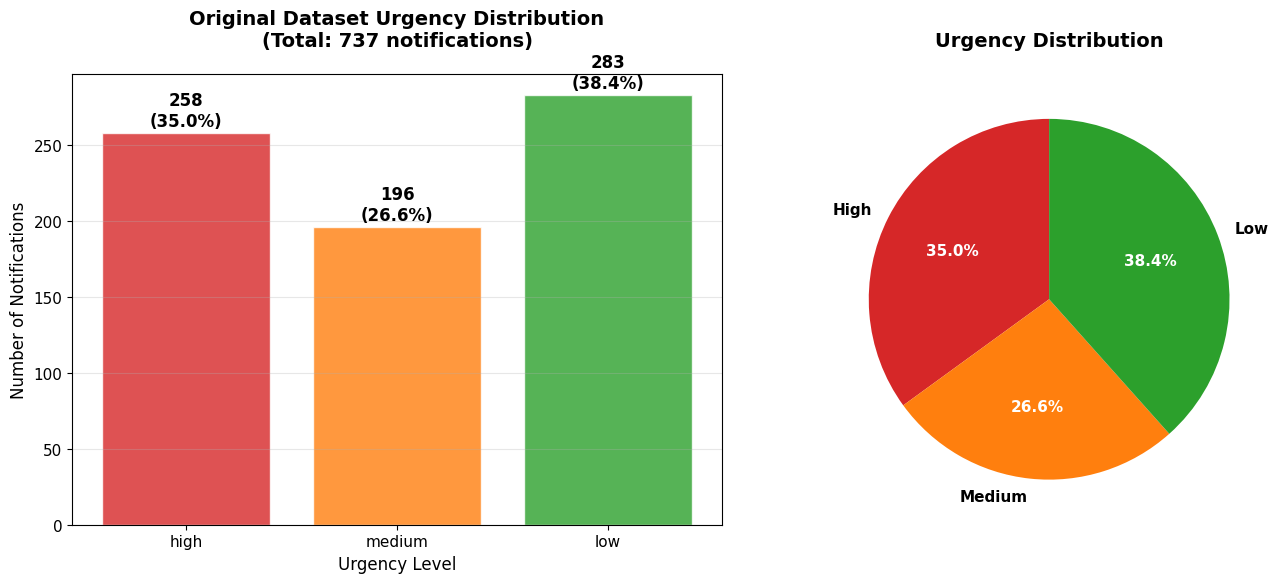


🎨 Creating app distribution analysis...
💾 Saved 'App Distribution Analysis' as: fig2_app_distribution.png, fig2_app_distribution.pdf, fig2_app_distribution.svg


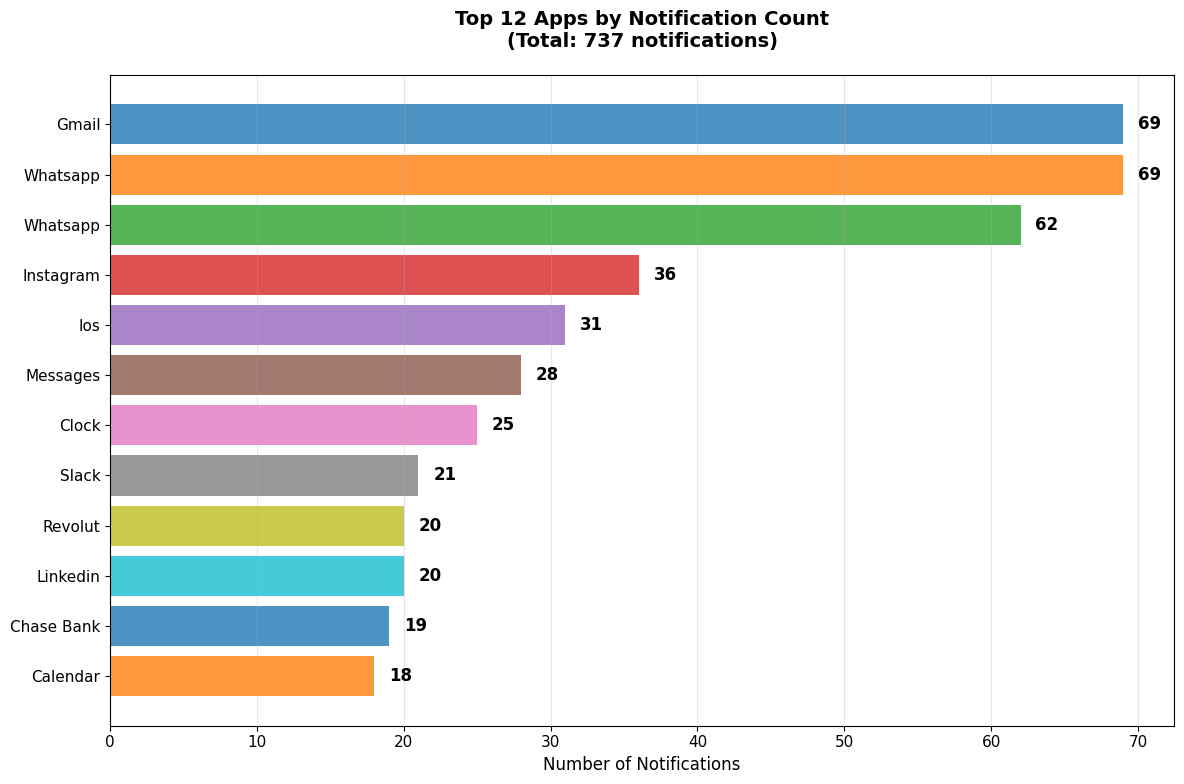


🎨 Creating text length analysis...
💾 Saved 'Text Length Analysis' as: fig3_text_length_analysis.png, fig3_text_length_analysis.pdf, fig3_text_length_analysis.svg


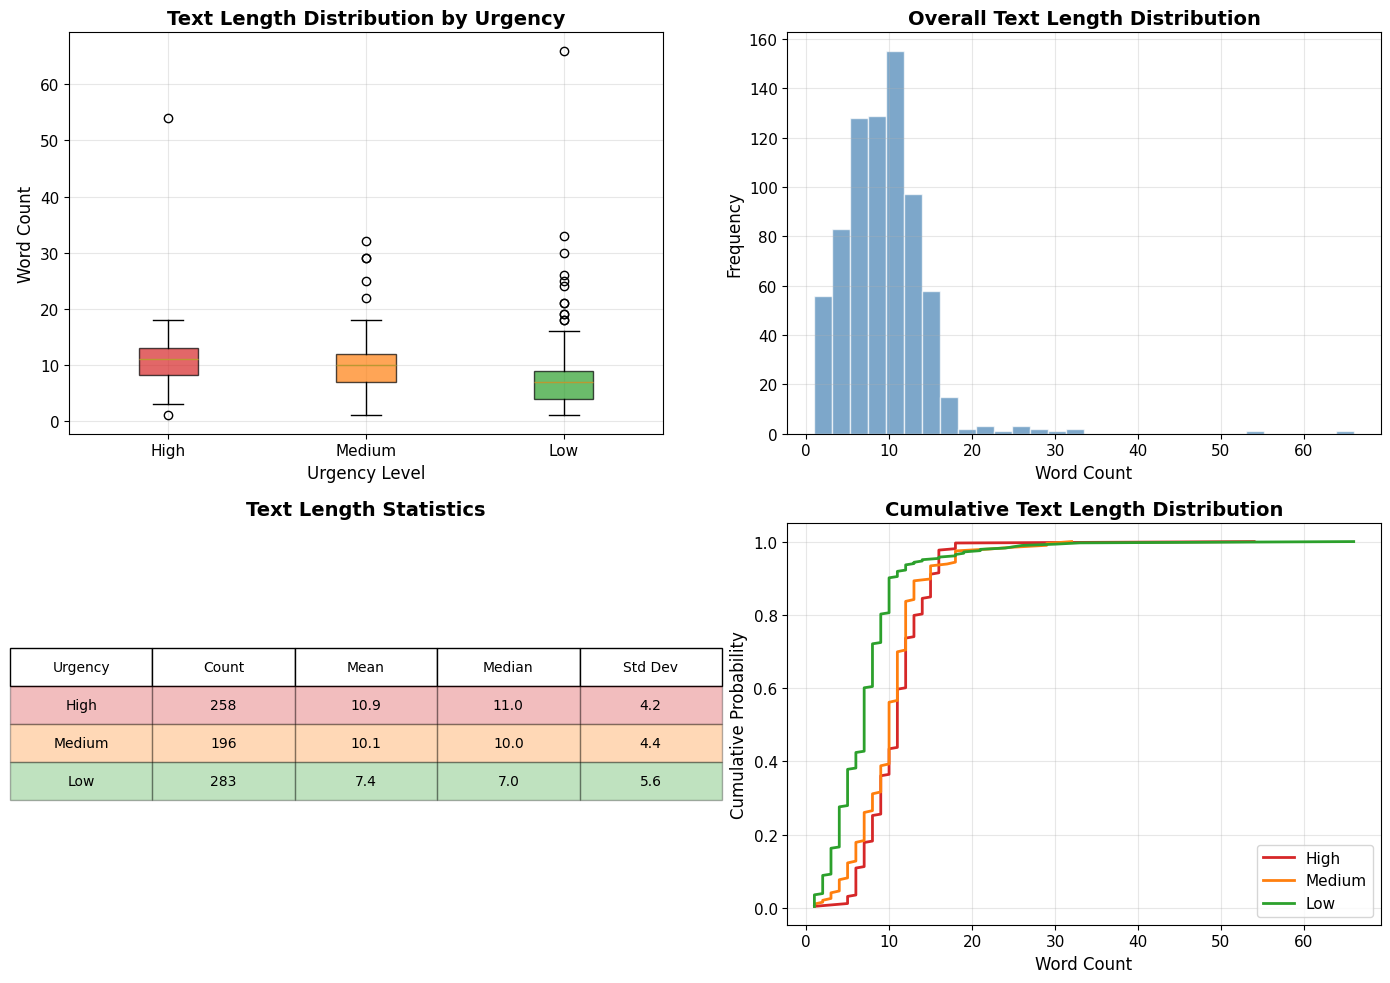


🎨 Creating data splits visualization...
💾 Saved 'Data Splits Analysis' as: fig4_data_splits_analysis.png, fig4_data_splits_analysis.pdf, fig4_data_splits_analysis.svg


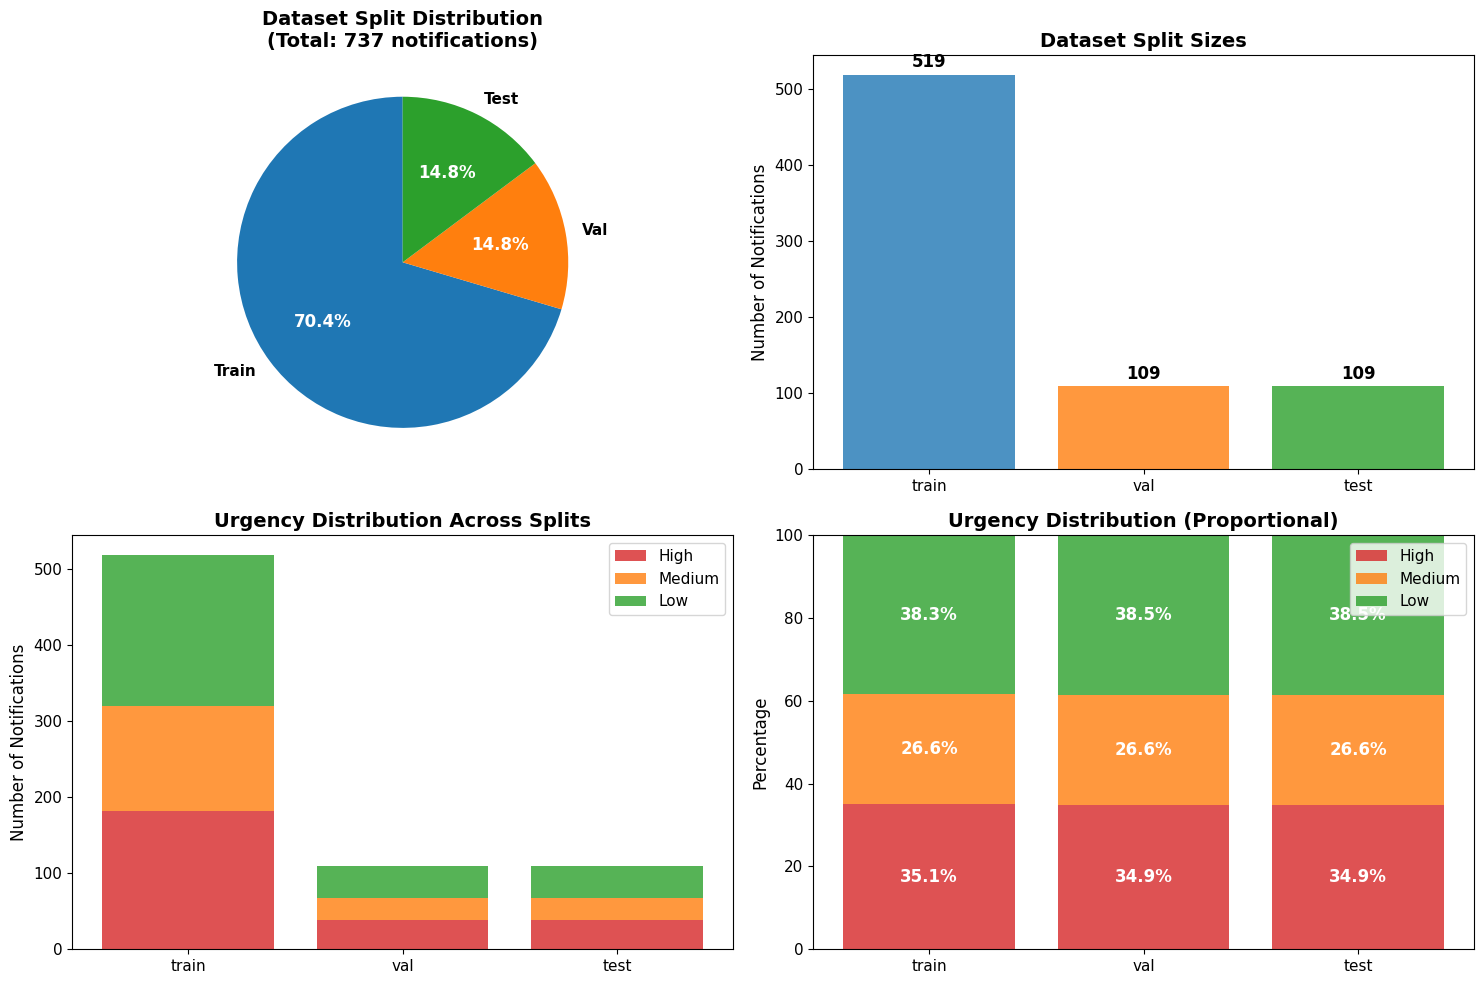


🎨 Creating preprocessing quality visualization...
💾 Saved 'Preprocessing Quality Assessment' as: fig5_preprocessing_quality.png, fig5_preprocessing_quality.pdf, fig5_preprocessing_quality.svg


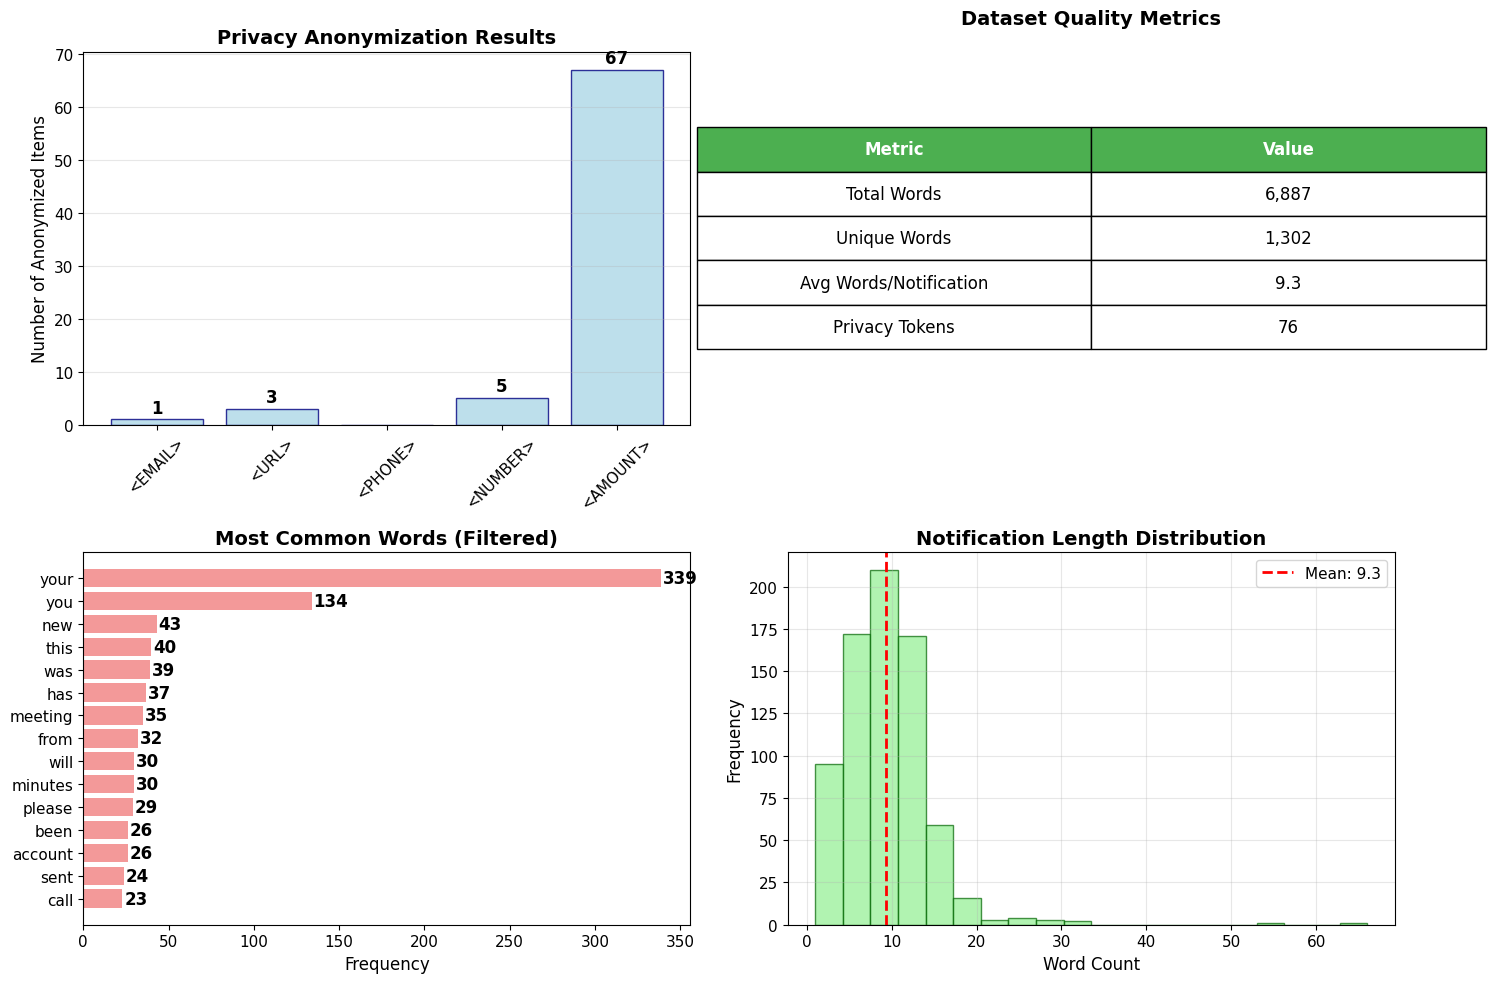


🎨 Creating before/after preprocessing comparison...
💾 Saved 'Before/After Preprocessing Comparison' as: fig6_before_after_comparison.png, fig6_before_after_comparison.pdf, fig6_before_after_comparison.svg


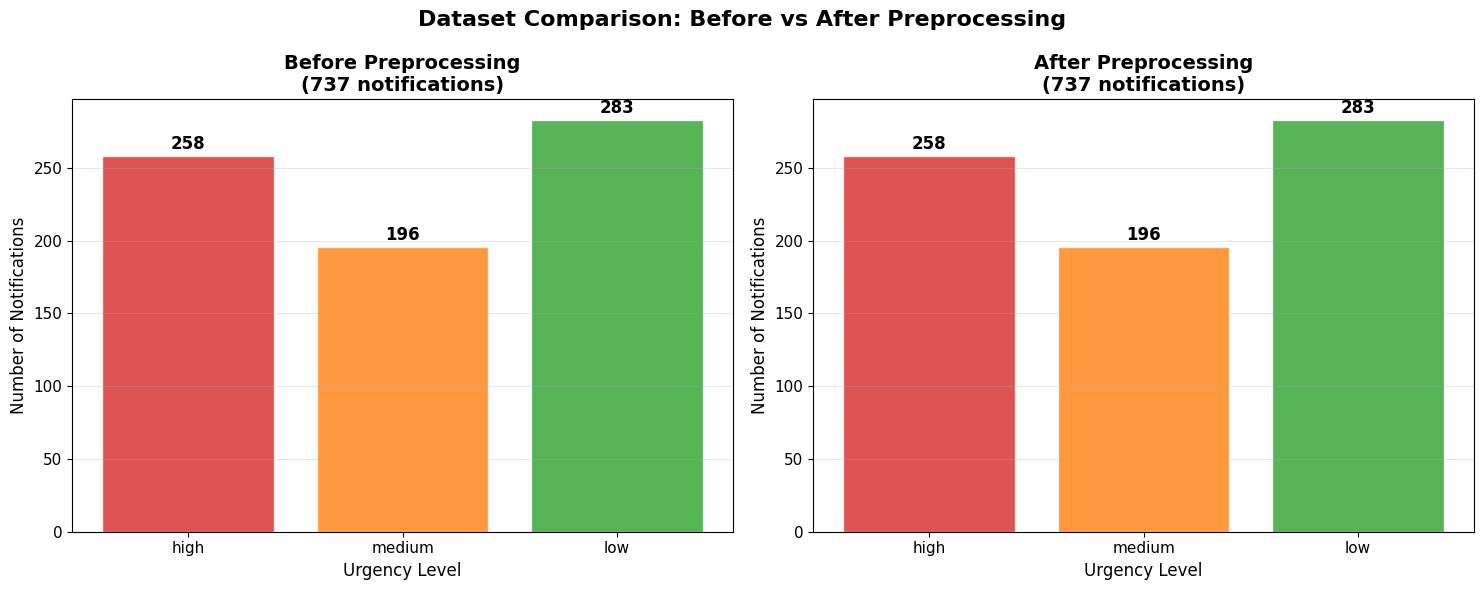


🎉 All visualizations generated successfully!
📁 Figures saved in: ../results/figures

📋 Available figures for your paper:
  1. fig1_overall_urgency_distribution - Shows the distribution of urgency levels in your dataset
  2. fig2_app_distribution - Shows which apps generate the most notifications
  3. fig3_text_length_analysis - Analyzes notification text length patterns by urgency
  4. fig4_data_splits_analysis - Shows your train/validation/test split distributions
  5. fig5_preprocessing_quality - Shows anonymization results and data quality metrics
  6. fig6_before_after_comparison - Compares dataset before and after preprocessing


In [ ]:
## 📊 Generate All Visualizations for Paper

# 1. Overall Dataset Distribution (Raw Data)
if 'raw_data' in locals() and raw_data:
    print("🎨 Creating overall dataset distribution...")
    fig1 = create_urgency_distribution_plot(raw_data, "Original Dataset Urgency Distribution")
    save_figure(fig1, "fig1_overall_urgency_distribution", "Overall Dataset Distribution")
    plt.show()

# 2. App Distribution Analysis
if 'raw_data' in locals() and raw_data:
    print("\n🎨 Creating app distribution analysis...")
    fig2 = create_app_distribution_plot(raw_data, top_n=12)
    save_figure(fig2, "fig2_app_distribution", "App Distribution Analysis")
    plt.show()

# 3. Text Length Analysis
if 'raw_data' in locals() and raw_data:
    print("\n🎨 Creating text length analysis...")
    fig3 = create_text_length_analysis(raw_data)
    save_figure(fig3, "fig3_text_length_analysis", "Text Length Analysis")
    plt.show()

# 4. Data Splits Visualization (Processed Data)
if 'processed_splits' in locals() and processed_splits:
    print("\n🎨 Creating data splits visualization...")
    fig4 = create_data_splits_visualization(processed_splits)
    save_figure(fig4, "fig4_data_splits_analysis", "Data Splits Analysis")
    plt.show()

# 5. Preprocessing Quality Assessment
if 'all_processed_data' in locals() and all_processed_data:
    print("\n🎨 Creating preprocessing quality visualization...")
    fig5 = create_preprocessing_quality_visualization(all_processed_data)
    save_figure(fig5, "fig5_preprocessing_quality", "Preprocessing Quality Assessment")
    plt.show()

# 6. Summary Statistics Comparison
if 'raw_data' in locals() and 'all_processed_data' in locals():
    print("\n🎨 Creating before/after preprocessing comparison...")
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Before preprocessing
    raw_urgency = Counter([item['urgency'] for item in raw_data])
    urgencies = ['high', 'medium', 'low']
    raw_counts = [raw_urgency.get(urgency, 0) for urgency in urgencies]
    colors = [URGENCY_COLORS[urgency] for urgency in urgencies]
    
    bars1 = axes[0].bar(urgencies, raw_counts, color=colors, alpha=0.8, edgecolor='white')
    axes[0].set_title(f'Before Preprocessing\n({len(raw_data)} notifications)', fontweight='bold')
    axes[0].set_xlabel('Urgency Level')
    axes[0].set_ylabel('Number of Notifications')
    axes[0].grid(axis='y', alpha=0.3)
    
    for bar, count in zip(bars1, raw_counts):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                    f'{count}', ha='center', va='bottom', fontweight='bold')
    
    # After preprocessing
    processed_urgency = Counter([item['urgency'] for item in all_processed_data])
    processed_counts = [processed_urgency.get(urgency, 0) for urgency in urgencies]
    
    bars2 = axes[1].bar(urgencies, processed_counts, color=colors, alpha=0.8, edgecolor='white')
    axes[1].set_title(f'After Preprocessing\n({len(all_processed_data)} notifications)', fontweight='bold')
    axes[1].set_xlabel('Urgency Level')
    axes[1].set_ylabel('Number of Notifications')
    axes[1].grid(axis='y', alpha=0.3)
    
    for bar, count in zip(bars2, processed_counts):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                    f'{count}', ha='center', va='bottom', fontweight='bold')
    
    plt.suptitle('Dataset Comparison: Before vs After Preprocessing', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    save_figure(fig, "fig6_before_after_comparison", "Before/After Preprocessing Comparison")
    plt.show()

print("\n🎉 All visualizations generated successfully!")
print(f"📁 Figures saved in: {output_dir}")
print("\n📋 Available figures for your paper:")
figure_descriptions = [
    "fig1_overall_urgency_distribution - Shows the distribution of urgency levels in your dataset",
    "fig2_app_distribution - Shows which apps generate the most notifications", 
    "fig3_text_length_analysis - Analyzes notification text length patterns by urgency",
    "fig4_data_splits_analysis - Shows your train/validation/test split distributions",
    "fig5_preprocessing_quality - Shows anonymization results and data quality metrics",
    "fig6_before_after_comparison - Compares dataset before and after preprocessing"
]

for i, desc in enumerate(figure_descriptions, 1):
    print(f"  {i}. {desc}")

## 6. Privacy Protection and Text Sanitization

To protect privacy and create consistent text for model training, we'll mask sensitive information like emails, phone numbers, and URLs with placeholder tokens.

In [ ]:
def sanitize_text(text):
    """
    Remove or mask sensitive information from notification text.
    
    Args:
        text (str): Input text to sanitize
        
    Returns:
        str: Sanitized text with sensitive info masked
    """
    if pd.isna(text) or text == '':
        return text
    
    text = str(text)
    
    # Email addresses
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    text = re.sub(email_pattern, '<EMAIL>', text)
    
    # Phone numbers (various formats)
    phone_patterns = [
        r'\b\d{3}-\d{3}-\d{4}\b',  # 123-456-7890
        r'\b\(\d{3}\)\s*\d{3}-\d{4}\b',  # (123) 456-7890
        r'\b\d{3}\.\d{3}\.\d{4}\b',  # 123.456.7890
        r'\b\+?\d{1,4}[\s-]?\d{3,4}[\s-]?\d{3,4}[\s-]?\d{3,4}\b',  # International
        r'\b\d{10,15}\b'  # Long number sequences
    ]
    for pattern in phone_patterns:
        text = re.sub(pattern, '<PHONE>', text)
    
    # URLs and links
    url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
    text = re.sub(url_pattern, '<URL>', text)
    
    # Domain names without http
    domain_pattern = r'\b(?:[a-zA-Z0-9-]+\.)+[a-zA-Z]{2,}\b'
    text = re.sub(domain_pattern, '<DOMAIN>', text)
    
    # Credit card numbers (basic)
    cc_pattern = r'\b\d{4}[\s-]?\d{4}[\s-]?\d{4}[\s-]?\d{4}\b'
    text = re.sub(cc_pattern, '<CARD>', text)
    
    # OTP/verification codes (3-8 digit sequences)
    otp_pattern = r'\b\d{3,8}\b'
    # Only replace if it looks like a code (not part of larger number)
    text = re.sub(r'\b(?:code|otp|pin|verify).*?(\d{3,8})\b', r'<CODE>', text, flags=re.IGNORECASE)
    
    # ZIP codes (US format)
    zip_pattern = r'\b\d{5}(?:-\d{4})?\b'
    text = re.sub(zip_pattern, '<ZIP>', text)
    
    # Clean up multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def apply_text_sanitization(df, text_column='combined_text'):
    """
    Apply text sanitization to the specified column.
    
    Args:
        df (DataFrame): Input dataframe
        text_column (str): Name of the text column to sanitize
        
    Returns:
        DataFrame: Dataframe with sanitized text
    """
    df_sanitized = df.copy()
    
    if text_column not in df.columns:
        print(f"❌ Column '{text_column}' not found in dataframe")
        return df_sanitized
    
    print(f"🔒 Sanitizing {text_column} column...")
    
    # Count sensitive patterns before sanitization
    original_text = df_sanitized[text_column].astype(str)
    
    # Apply sanitization
    df_sanitized[f'{text_column}_sanitized'] = df_sanitized[text_column].apply(sanitize_text)
    
    # Count replacements made
    sanitized_text = df_sanitized[f'{text_column}_sanitized'].astype(str)
    
    patterns = {
        'Emails': '<EMAIL>',
        'Phone numbers': '<PHONE>', 
        'URLs': '<URL>',
        'Domains': '<DOMAIN>',
        'Cards': '<CARD>',
        'Codes': '<CODE>',
        'ZIP codes': '<ZIP>'
    }
    
    print("📊 Sanitization results:")
    for pattern_name, placeholder in patterns.items():
        count = sanitized_text.str.contains(re.escape(placeholder), regex=True).sum()
        if count > 0:
            print(f"  - {pattern_name}: {count} instances masked")
    
    # Show example of sanitization
    changed_mask = original_text != sanitized_text
    if changed_mask.any():
        print(f"\n📝 Example of sanitization:")
        example_idx = changed_mask.idxmax()
        print(f"Before: '{original_text.iloc[example_idx][:100]}...'")
        print(f"After:  '{sanitized_text.iloc[example_idx][:100]}...'")
    else:
        print("✓ No sensitive patterns detected in text")
    
    return df_sanitized

# Apply text sanitization
if 'df_cleaned' in locals() and df_cleaned is not None:
    df_sanitized = apply_text_sanitization(df_cleaned, 'combined_text')
    print(f"\n✅ Text sanitization completed")
    print(f"Dataset shape: {df_sanitized.shape}")
else:
    print("❌ No cleaned dataset available. Please run previous cells first.")

## 7. Data Labeling (Priority Classification)

If the dataset doesn't include priority labels, we'll create urgency labels based on the notification content using predefined rules. Our target classes are:

- **High**: Urgent/time-sensitive (security alerts, OTP codes, payment failures, meetings starting now)
- **Medium**: Important but not immediate (delivery updates, reminders for later today) 
- **Low**: Non-urgent (promotions, newsletters, social updates, general news)

In [ ]:
def assign_priority_labels(text):
    """
    Assign priority labels based on notification text content.
    
    Args:
        text (str): Notification text to classify
        
    Returns:
        str: Priority level ('High', 'Medium', 'Low')
    """
    if pd.isna(text) or text == '':
        return 'Low'
    
    text_lower = str(text).lower()
    
    # High priority keywords and phrases
    high_priority_patterns = [
        # Security & urgent actions
        r'\b(security|breach|hack|fraud|unauthorized|suspicious)\b',
        r'\b(verify|confirm|authenticate).*?(now|immediately|asap|urgent)\b',
        r'\b(login|sign[\s-]?in).*?(attempt|failed|blocked)\b',
        
        # Payment & financial
        r'\b(payment|transaction).*?(failed|declined|error|problem)\b',
        r'\b(account|card).*?(suspended|blocked|locked|frozen)\b',
        r'\b(insufficient|low).*?funds?\b',
        
        # Time-sensitive
        r'\b(expire|expires?|expired).*?(today|soon|now)\b',
        r'\b(urgent|emergency|critical|important|asap)\b',
        r'\b(starting|begins?|happening).*?(now|soon|in.*?minutes?)\b',
        r'\b(last.*?chance|final.*?notice|immediate.*?action)\b',
        
        # OTPs and codes  
        r'\b(otp|verification|confirm|authenticate).*?<CODE>\b',
        r'\b<CODE>.*?(otp|verification|confirm)\b',
        
        # Meetings and calls
        r'\b(meeting|call|conference).*?(starting|begins?|now)\b',
        r'\b(late|missed).*?(meeting|call|appointment)\b'
    ]
    
    # Medium priority keywords and phrases
    medium_priority_patterns = [
        # Delivery and shipping
        r'\b(package|delivery|shipped|tracking|order).*?(update|status|arrived|delivered)\b',
        r'\b(out.*?for.*?delivery|delivery.*?attempt)\b',
        
        # Reminders and appointments
        r'\b(reminder|appointment|meeting|event).*?(tomorrow|later|upcoming)\b',
        r'\b(due|deadline).*?(tomorrow|next|week|month)\b',
        
        # Account updates (non-urgent)
        r'\b(account|profile|settings).*?(updated|changed|modified)\b',
        r'\b(password|email).*?(changed|updated|reset)\b',
        
        # News and updates (important)
        r'\b(update|news|announcement).*?(important|new|latest)\b',
        r'\b(policy|terms).*?(updated|changed|new)\b'
    ]
    
    # Check for high priority patterns
    for pattern in high_priority_patterns:
        if re.search(pattern, text_lower):
            return 'High'
    
    # Check for medium priority patterns
    for pattern in medium_priority_patterns:
        if re.search(pattern, text_lower):
            return 'Medium'
    
    # Common low priority patterns (promotional, social, etc.)
    low_priority_patterns = [
        r'\b(sale|discount|offer|deal|promotion|coupon)\b',
        r'\b(newsletter|subscribe|follow|like|share)\b',
        r'\b(recommended|suggested|you.*?might.*?like)\b',
        r'\b(new.*?post|friend.*?request|follower|activity)\b',
        r'\b(weather|news|entertainment|sports|celebrity)\b'
    ]
    
    # Check for explicit low priority patterns
    for pattern in low_priority_patterns:
        if re.search(pattern, text_lower):
            return 'Low'
    
    # Default to Low for general notifications
    return 'Low'

def create_priority_labels(df, text_column='combined_text_sanitized'):
    """
    Apply priority labeling to the dataset.
    
    Args:
        df (DataFrame): Input dataframe
        text_column (str): Column containing notification text
        
    Returns:
        DataFrame: Dataframe with priority labels
    """
    df_labeled = df.copy()
    
    if text_column not in df.columns:
        print(f"❌ Column '{text_column}' not found")
        return df_labeled
    
    print(f"🎯 Assigning priority labels based on {text_column}...")
    
    # Apply labeling
    df_labeled['priority'] = df_labeled[text_column].apply(assign_priority_labels)
    
    # Show distribution
    priority_counts = df_labeled['priority'].value_counts()
    priority_pct = df_labeled['priority'].value_counts(normalize=True) * 100
    
    print(f"\n📊 Priority Distribution:")
    for priority in ['High', 'Medium', 'Low']:
        count = priority_counts.get(priority, 0)
        pct = priority_pct.get(priority, 0)
        print(f"  {priority}: {count:,} ({pct:.1f}%)")
    
    # Show examples for each priority level
    print(f"\n📝 Examples by Priority Level:")
    for priority in ['High', 'Medium', 'Low']:
        examples = df_labeled[df_labeled['priority'] == priority][text_column].head(3)
        if len(examples) > 0:
            print(f"\n{priority} Priority Examples:")
            for i, text in enumerate(examples, 1):
                print(f"  {i}. '{text[:80]}...'")
    
    return df_labeled

# Check if we need to create labels or if they already exist
if 'df_sanitized' in locals() and df_sanitized is not None:
    
    # Check for existing priority/urgency columns
    existing_priority_cols = []
    for col in df_sanitized.columns:
        if any(keyword in col.lower() for keyword in ['priority', 'urgency', 'importance', 'level', 'class']):
            existing_priority_cols.append(col)
    
    if existing_priority_cols:
        print(f"✓ Found existing priority columns: {existing_priority_cols}")
        print("Using existing labels...")
        
        # Use the first priority column found
        priority_col = existing_priority_cols[0]
        df_labeled = df_sanitized.copy()
        
        if priority_col != 'priority':
            df_labeled['priority'] = df_labeled[priority_col]
        
        print(f"Priority distribution from {priority_col}:")
        print(df_labeled['priority'].value_counts())
        
    else:
        print("📋 No existing priority labels found. Creating new labels...")
        df_labeled = create_priority_labels(df_sanitized)
        
else:
    print("❌ No sanitized dataset available. Please run previous cells first.")

## 8. Train-Validation-Test Split

We'll create a stratified split of the data to ensure balanced representation of priority classes across train/validation/test sets.

In [ ]:
def create_data_splits(df, text_column='combined_text_sanitized', target_column='priority', 
                      train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """Create stratified train/validation/test splits."""
    
    print(f"📊 Creating data splits...")
    print(f"Ratios - Train: {train_ratio:.1%}, Val: {val_ratio:.1%}, Test: {test_ratio:.1%}")
    
    # Verify ratios sum to 1
    if not abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6:
        raise ValueError("Split ratios must sum to 1.0")
    
    # Prepare data
    df_split = df[[text_column, target_column]].copy()
    df_split = df_split.dropna()  # Remove any remaining NaN values
    
    print(f"Total samples: {len(df_split)}")
    print(f"Class distribution:")
    class_counts = df_split[target_column].value_counts()
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} ({count/len(df_split):.1%})")
    
    # First split: train vs (val + test)
    X = df_split[text_column]
    y = df_split[target_column]
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(val_ratio + test_ratio), stratify=y, random_state=random_state
    )
    
    # Second split: val vs test
    val_size_adjusted = val_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_size_adjusted), stratify=y_temp, random_state=random_state
    )
    
    # Create DataFrames
    train_df = pd.DataFrame({text_column: X_train, target_column: y_train}).reset_index(drop=True)
    val_df = pd.DataFrame({text_column: X_val, target_column: y_val}).reset_index(drop=True)
    test_df = pd.DataFrame({text_column: X_test, target_column: y_test}).reset_index(drop=True)
    
    print(f"\n✅ Data splits created!")
    print(f"  Train: {len(train_df):,} ({len(train_df)/len(df_split):.1%})")
    print(f"  Val: {len(val_df):,} ({len(val_df)/len(df_split):.1%})")
    print(f"  Test: {len(test_df):,} ({len(test_df)/len(df_split):.1%})")
    
    return train_df, val_df, test_df

# Create data splits (simplified without heavy visualizations)
if 'df_labeled' in locals() and df_labeled is not None:
    train_df, val_df, test_df = create_data_splits(df_labeled)
    print("\n📊 Split distribution:")
    for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        counts = df['priority'].value_counts()
        print(f"{name}: {dict(counts)}")
else:
    print("❌ No labeled dataset available. Please run previous cells first.")

## 9. Export Processed Data

Finally, we'll save our cleaned and split datasets for use in model training and evaluation.

In [ ]:
def export_processed_data(train_df, val_df, test_df, export_dir="../data/processed"):
    """Export the processed datasets to CSV files."""
    
    export_path = Path(export_dir)
    export_path.mkdir(parents=True, exist_ok=True)
    
    print(f"💾 Exporting to: {export_path.resolve()}")
    
    # Export datasets
    datasets = [('train', train_df), ('val', val_df), ('test', test_df)]
    
    for name, df in datasets:
        filepath = export_path / f"notifications_{name}.csv"
        df.to_csv(filepath, index=False)
        print(f"✓ Saved {name}: {len(df):,} samples")
    
    # Export complete dataset
    complete_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    complete_df.to_csv(export_path / "notifications_complete.csv", index=False)
    print(f"✓ Saved complete: {len(complete_df):,} samples")
    
    print(f"\n✅ Data processing pipeline completed!")
    return export_path

# Export the data
if all(var in locals() for var in ['train_df', 'val_df', 'test_df']):
    export_path = export_processed_data(train_df, val_df, test_df)
    print(f"\n🚀 Ready for model training!")
    print(f"Data exported to: {export_path}")
else:
    print("❌ Data splits not available. Please run previous cells first.")